## Preamble

In [8]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=4

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1

print('h,nz,nx=',h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print('dt,nt=',dt,nt)

dt=0.0026
nt=int(T/dt)
print('adjusted dt,nt=',dt,nt)

ntr=670

h,nz,nx= 21 143 810
dt,nt= 0.0026272340425531914 1903
adjusted dt,nt= 0.0026 1923


In [9]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,cmap='viridis',#cmap='jet',
           title=None,grid=True, label=None, colorbar=False, colorbar_title=None,
           extent=[0,(nx-1)*h/1000 , (nz-1)*h/1000, 0 ]):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    im=plt.imshow(data,vmin=clipp[0],vmax=clipp[1],cmap=cmap,aspect='auto',extent=extent)
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    if colorbar: plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    if label!=None:plt.xlabel(label[0]); plt.ylabel(label[1])
    if title!=None: plt.title(title)
    if colorbar_title!=None:
        cbar = plt.colorbar(im);cbar.ax.set_title(colorbar_title)

def imshow_shot(data,perc=None,clip=None,clipmin=None,cmap='gray',colorbar=None,title=None,grid=True, label=None):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],cmap=cmap,aspect='auto',extent=[0,(nx-1)*h/1000 , (nt-1)*dt, 0 ])
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    if colorbar!=None: plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    if label!=None: plt.xlabel(label[0]); plt.ylabel(label[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > $out
        
def run_remote(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ./run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ./run.sh > {out}")

## Prepare

In [3]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [4]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
# !segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
# !segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00144723 s, 2.2 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00190142 s, 1.7 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801


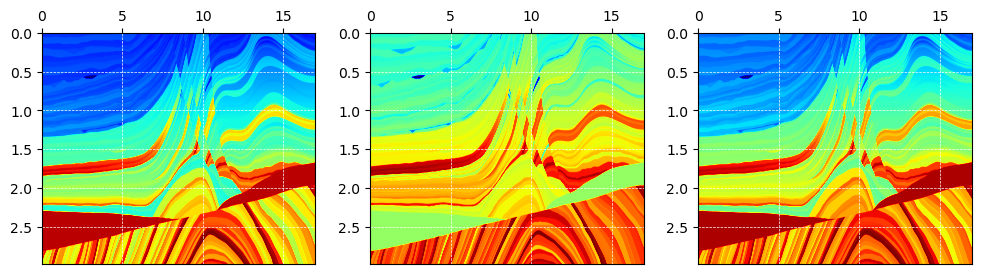

In [5]:
#chop the water layer
vp = read('../11_Marmousi/vp.bin',(13601,2801)) [405:,:]
rho= read('../11_Marmousi/rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
# qp = vp**0.75 #leads to a range of ~200--550, not yet instability
# qp = vp**0.6 #65-160
qp = vp**0.55 #40-110

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

In [6]:
print(vp.shape)
print(qp.min())
print(qp.max())

(2396, 13601)
45.35198
104.62943


In [7]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [10]:
##downsample true models
#!make -B true

##make init models
#!make -B init

#catenate
str=f'cat vpt.{h}m   rhot.{h}m   qpt.{h}m  > true'
!$str
!cat vpt.init  rhot.init  qpt.init > init

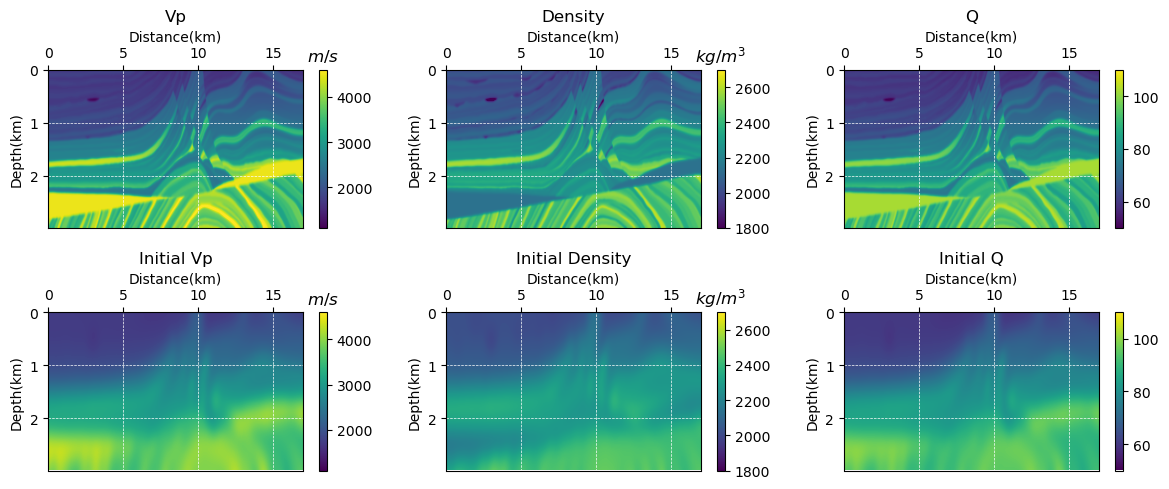

In [34]:
#plot

plt.figure(figsize=(12,5))

true=read('true',(3*nx,nz))
plt.subplot(2,3,1); imshow(true[:,:nx],title='Vp',clip=[1100,4600],colorbar_title=r'$m/s$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,2); imshow(true[:,nx:2*nx],title='Density',clip=[1800,2700],colorbar_title=r'$kg/m^3$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,3); imshow(true[:,2*nx:],title='Q',clip=[50,110],colorbar_title=' ',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.savefig('./figures/True models.svg',bbox_inches='tight',transparent=True)

# plt.figure(figsize=(15,3))
init=read('init',(3*nx,nz))
plt.subplot(2,3,4); imshow(init[:,:nx],title='Initial Vp',clip=[1100,4600],colorbar_title=r'$m/s$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,5); imshow(init[:,nx:2*nx],title='Initial Density',clip=[1800,2700],colorbar_title=r'$kg/m^3$',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,6); imshow(init[:,2*nx:],title='Initial Q',clip=[50,110],colorbar_title=' ',label=['Distance(km)','Depth(km)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.tight_layout()
#plt.savefig('./figures/True and Initial models.svg',bbox_inches='tight',transparent=True)

In [13]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())
print(init[:,2*nx:].min())

1142.8925 4691.6123
58.811752


In [10]:
%%writefile setup_default

MODEL_SIZE              '143 810  1'
MODEL_SPACING           '21  21   1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho qp'
MODEL_ATTRIBUTES_WRITE   'vp qp'
#FILE_TOPO              'topo'

IS_FREESURFACE          F
FREE_SURFACE_PPG        T
IS_Q_ATTENUATION        T
IF_HICKS                T
IF_BLOOM                T

ACQUI_GEOMETRY          spread
FS                      '  21   1200  0'
#DS                     '  0   100   0'
#NS                     144
DS                      '  0   400  0'
NS                      36
FR                      '  21   0   0'
DR                      '  0   25  0'
NR                       670

SCOMP                   dpdz  #p
RCOMP                   dpdz  #p
IF_MUST_USE_RCOMP       T

WAVELET_TYPE            ricker

FPEAK        4
NT           1923
DT           0.0026

#SNAPSHOT      p
#NSNAPSHOT    50

#############
## for FWI ##
#############
FILE_DATA_PREFIX    './results_obs/Ru_Shot'
WEIGHTING           'none'

UPDATE_WAVELET      no

PARAMETER           'vp:1065:4700 qp:30:120'

SMOOTHING     'none'
#PRECO         'z^0'

JOB             gradient

MAX_ITERATE     40
MAX_MODELING    150


IF_USE_CHECKPOINT   F

Overwriting setup_default


## Observed data

In [23]:
!cp setup_default setup
# !rm -r ./
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
# !echo "FREE_SURFACE_PPG      T"  >> setup
# !echo "IF_HICKS         F" >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run_remote(out='out')

bash ./run.sh > out


In [25]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Mar 15 13:03 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:18:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cel

In [26]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
!echo "NS               1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
# !echo "FREE_SURFACE_PPG      T"  >> setup
# !echo "IS_FREESURFACE          F"  >> setup
!echo "IS_Q_ATTENUATION   T" >> setup
!echo "SNAPSHOT         p" >> setup
# !echo "IF_HICKS         F" >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run_remote(out='out')

bash ./run.sh > out


In [27]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Mar 15 13:03 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:19:09
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagon

/tmp/ipykernel_578792/3847517790.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,3,1); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Acoustic',label=['Distance(km)','Time(s)'])


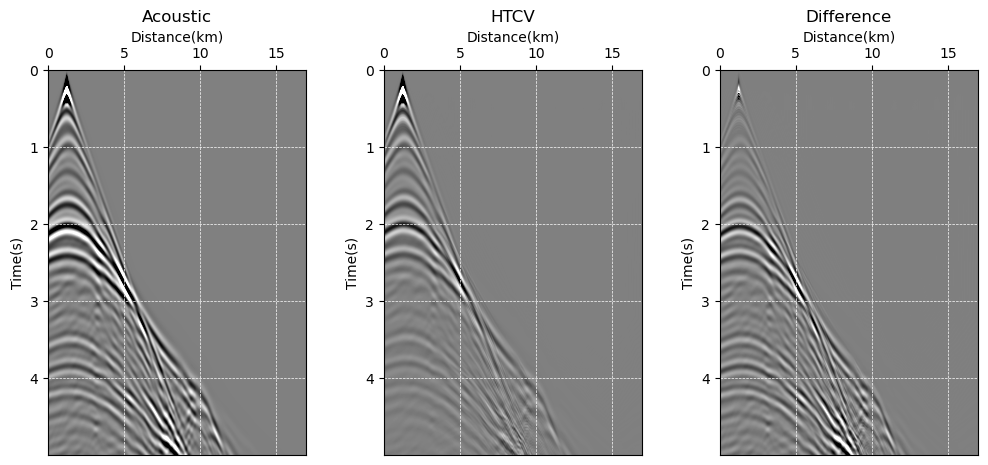

In [123]:
fig,ax=plt.subplots(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Acoustic',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow_shot(read_su('results_obs/Ru_Shot0001.su'    ),clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,3); imshow_shot(read_su('results_obs_noQ/Ru_Shot0001.su')-read_su('results_obs/Ru_Shot0001.su'),clip=[-0.01,0.01],title='Difference',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplots_adjust(wspace=0.3)
# plt.savefig('./figures/results_with_Q.svg',bbox_inches='tight',transparent=True)

In [29]:
a=read_su('results_obs_noQ/Ru_Shot0001.su')
a.shape

(1923, 670)

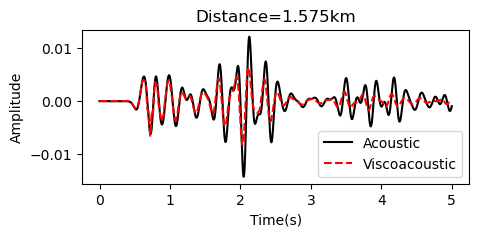

In [32]:
t=np.linspace(0,dt*nt,nt)
plt.figure(figsize=(5,2))
plt.plot(t,read_su('results_obs_noQ/Ru_Shot0001.su')[:,75],color='k')
plt.plot(t,read_su('results_obs/Ru_Shot0001.su'    )[:,75],'--r')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude')
plt.title(f'Distance={75*h/1000}km')
plt.legend(['Acoustic', 'Viscoacoustic'])
#plt.savefig('./figures/1shot_compare.png',bbox_inches='tight',transparent=True)

## FWI gradient

In [33]:
!cp setup_default setup
!rm -r ./results_grad_noQ
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "SNAPSHOT      p"  >> setup
run_remote(app='../../exe/FWI',out='out')

rm: cannot remove './results_grad_noQ': No such file or directory
bash ./run.sh > out


In [34]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Mar 15 13:03 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:21:03
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil


In [35]:
!cp setup_default setup
!rm -r ./results_grad
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SNAPSHOT      p"  >> setup
run_remote(app='../../exe/FWI',out='out')

rm: cannot remove './results_grad': No such file or directory
bash ./run.sh > out


In [36]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Mar 15 13:03 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:22:33
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|

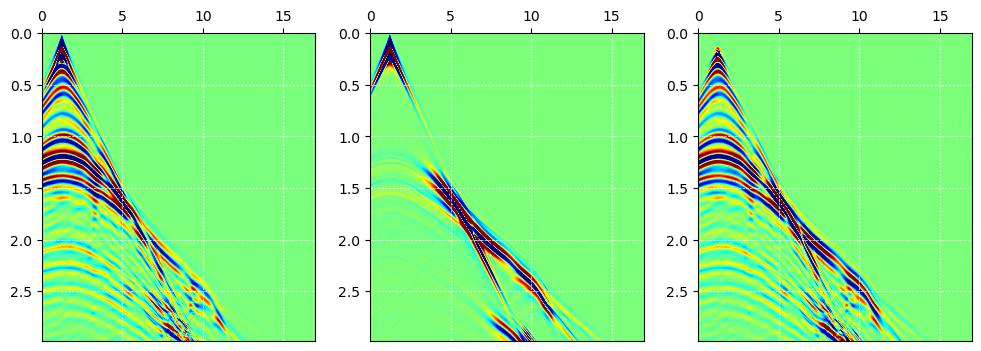

In [37]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su' ),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_grad/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_grad/dadj_Shot0001.su'),perc=98)

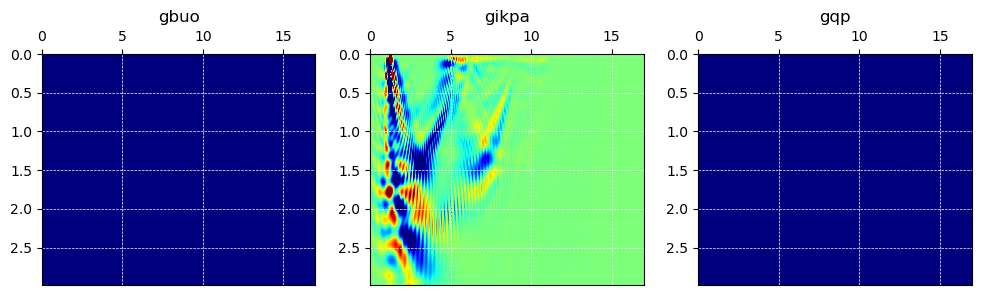

In [38]:
grad=read('results_grad_noQ/correlate_gradient',n=(3*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gbuo')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gikpa')
plt.subplot(1,3,3); imshow(grad[:,2*nx:],  perc=98,title='gqp')

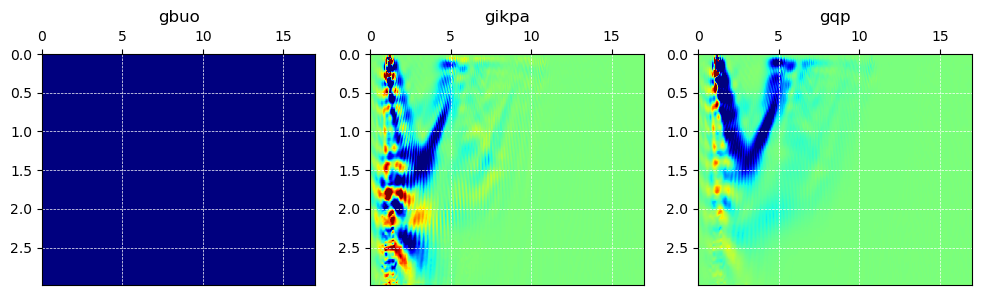

In [39]:
grad=read('results_grad/correlate_gradient',n=(3*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gbuo')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gikpa')
plt.subplot(1,3,3); imshow(grad[:,2*nx:],  perc=98,title='gqp')

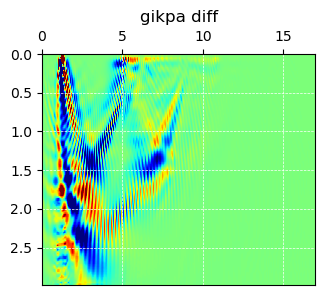

In [40]:

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results_grad_noQ/correlate_gradient',n=(3*nx,nz))[:,nx:2*nx]
                          -read('results_grad/correlate_gradient',n=(3*nx,nz))[:,nx:2*nx],
                           perc=98,title='gikpa diff')

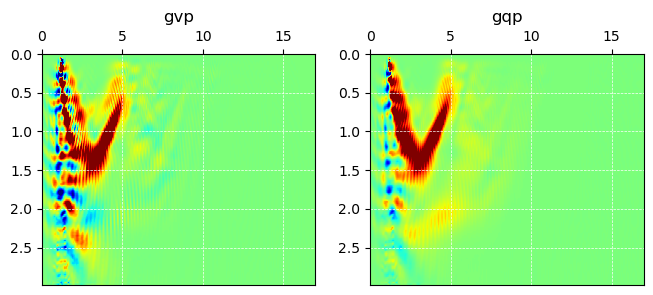

In [41]:
grad=read('results_grad/qp0%pg',n=(2*nx,nz))
          
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad[:,:nx],    perc=98,title='gvp')
plt.subplot(1,3,2); imshow(grad[:,nx:2*nx],perc=98,title='gqp')

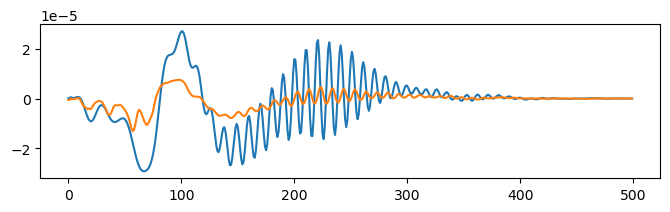

In [42]:
plt.figure(figsize=(8,2))
plt.plot(read('results_grad_noQ/qp0%pg',n=(2*nx,nz))[100,:500],label='no Q')
plt.plot(read('results_grad/qp0%pg',    n=(2*nx,nz))[100,:500],label='with Q')

In [43]:
def read3d(filename):
    return np.fromfile(filename,dtype='float32')

## Free Surface

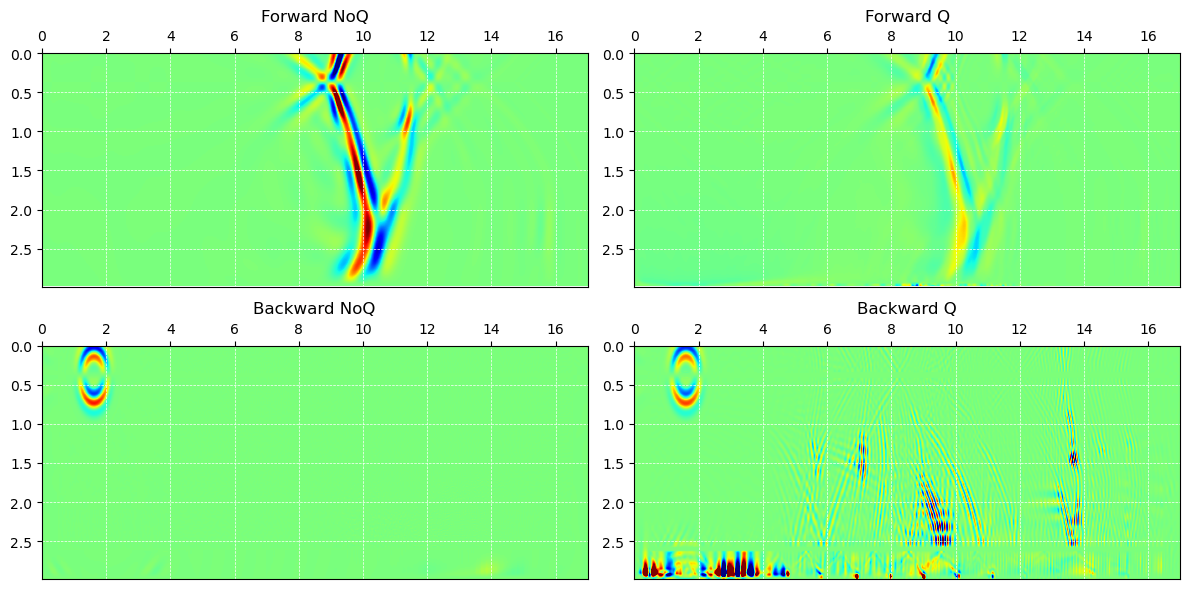

In [44]:
forward_noQ = read3d('./results_grad_noQ/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T
forward_Q = read3d('./results_grad/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T

rev_noQ = read3d('./results_grad_noQ/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T
rev_Q = read3d('./results_grad/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T

clip1=1
clip2=5
plt.figure(figsize=(12,6))
plt.subplot(2,2,1); imshow(forward_noQ[:,:,50],clip=[-clip1,clip1],title='Forward NoQ')
plt.subplot(2,2,2); imshow(forward_Q[:,:,50],clip=[-clip1,clip1],title='Forward Q')
plt.subplot(2,2,3); imshow(rev_noQ[:,:,45],clip=[-clip2,clip2],title='Backward NoQ')
plt.subplot(2,2,4); imshow(rev_Q[:,:,45],clip=[-clip2,clip2],title='Backward Q')
plt.tight_layout()

## No Freesurface

In [39]:

# forward_noQ_noFS = read3d('./results_grad_noQ_noFS/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T
# forward_Q_noFS = read3d('./results_grad_noFS/snap_fld_reU%p').reshape((-1,nx+48,nz+48)).T

# rev_noQ_noFS = read3d('./results_grad_noQ_noFS/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T
# rev_Q_noFS = read3d('./results_grad_noFS/snap_fld_reU%p_rev').reshape((-1,nx+48,nz+48)).T

# plt.figure(figsize=(12,6))
# plt.subplot(2,2,1); imshow(forward_noQ_noFS[:,:,45],clip=[-clip1,clip1],title='Forward NoQ')
# plt.subplot(2,2,2); imshow(forward_Q_noFS[:,:,45],clip=[-clip1,clip1],title='Forward Q')
# plt.subplot(2,2,3); imshow(rev_noQ_noFS[:,:,45],clip=[-clip2,clip2],title='Backward NoQ')
# plt.subplot(2,2,4); imshow(rev_Q_noFS[:,:,45],clip=[-clip2,clip2],title='Backward Q')
# plt.tight_layout()

## Multiple shots

### data

In [45]:
!cp setup_default setup
!rm -r results_obs_noQ/
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
run_remote(np=36,nthreads=1,out='out')

bash ./run.sh > out


In [46]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Mar 15 13:03 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:24:26
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cel

In [47]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
run_remote(np=36,nthreads=1,out='out')

bash ./run.sh > out


In [48]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Mar 15 13:03 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:28:54
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagon

### gradient

In [49]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "LAP_FRAC       '0.1 0.2 0.2' "  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
#~3min for one gradient

bash ./run.sh > out


In [50]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Mar 15 13:03 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:40:40
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil


In [51]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SMOOTHING        Laplacian "  >> setup
!echo "LAP_FRAC       '0.1 0.2 0.2' "  >> setup
!echo "PRECO            z^1.5       "  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

bash ./run.sh > out


In [52]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI_Q50
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Mar 15 13:03 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 2c18290
 Git Branch: VisAC_ZFL_WZ_v2
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 03/15/2026
System time: 13:44:42
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|

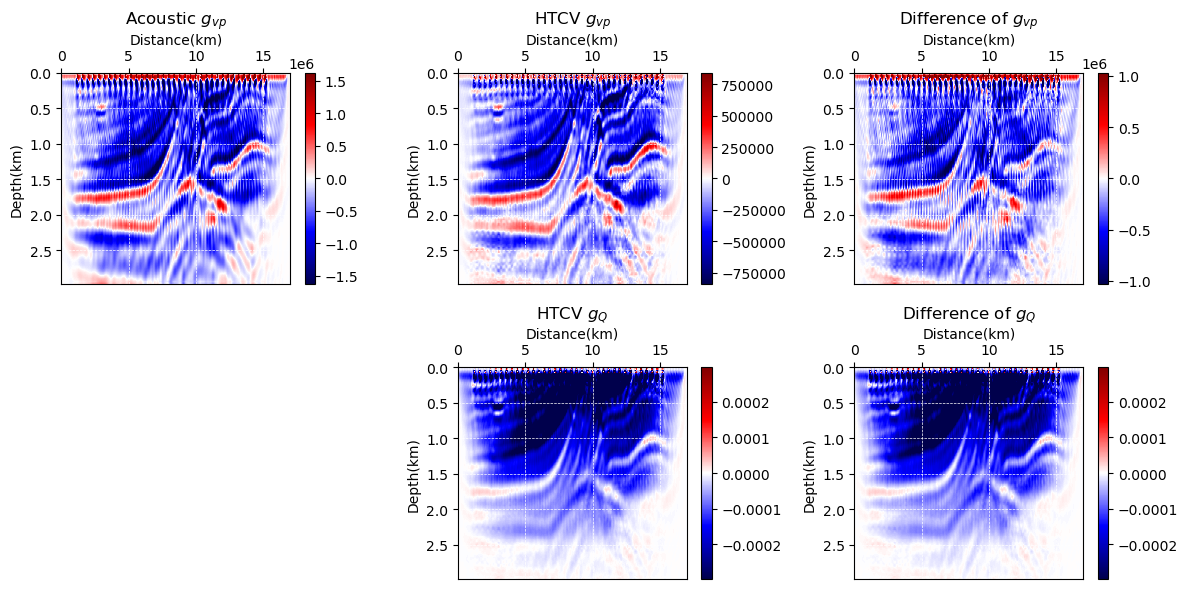

In [53]:
grad0=read('results_grad_noQ/correlate_gradient',(3*nx,nz)) [:,:]
grad1=read('results_grad/correlate_gradient'    ,(3*nx,nz)) [:,:]

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(grad0[:,nx:2*nx],perc=98,cmap='seismic',title=r'Acoustic $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title=''); ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,2); imshow(grad1[:,nx:2*nx],perc=98,cmap='seismic',title=r'HTCV $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,3); imshow(grad0[:,nx:2*nx]-grad1[:,nx:2*nx],perc=98,cmap='seismic',title=r'Difference of $g_{vp}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplot(2,3,4); imshow(grad0[:,2*nx:],perc=90,cmap='seismic',title=r'Acoustic $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,5); imshow(grad1[:,2*nx:],perc=90,cmap='seismic',title=r'HTCV $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,6); imshow(grad1[:,2*nx:]-grad0[:,2*nx:],perc=90,cmap='seismic',title=r'Difference of $g_{Q}$',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.tight_layout()
# plt.savefig('./figures/Gradients comparison.svg',bbox_inches='tight',transparent=True)


Text(0.5, 1.0, 'Distance=4.2km')

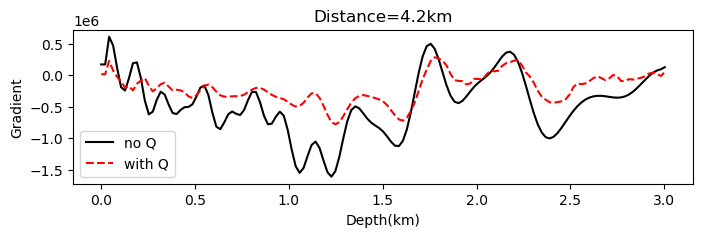

In [54]:
depth=np.linspace(0,h*nz,nz)/1000
plt.figure(figsize=(8,2))
plt.plot(depth,grad0[:,nx+200],color='k',label='Acoustic')
plt.plot(depth,grad1[:,nx+200],'--r',label='Viscoacoustic')
plt.legend(['no Q', 'with Q'])
plt.xlabel('Depth(km)')
plt.ylabel('Gradient')
plt.title(f'Distance={200*h/1000}km')
# plt.savefig('./figures/gradient_1shot_comparison.png',bbox_inches='tight',transparent=True)

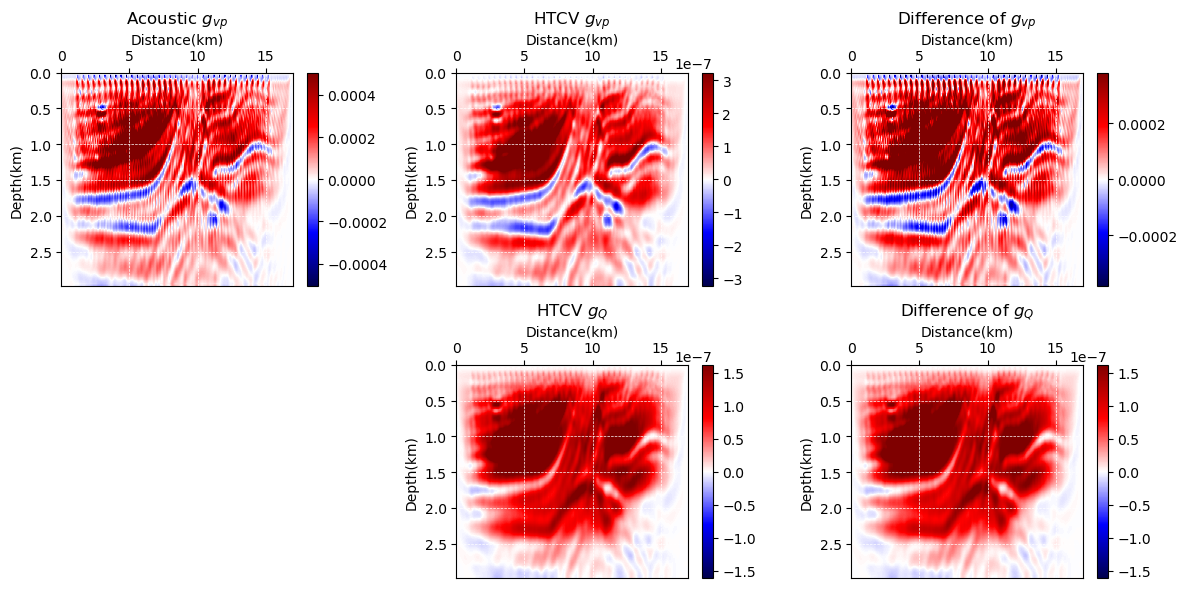

In [55]:
gradqp1=read('results_grad_noQ/qp0%pg',(2*nx,nz))
gradqp2=read('results_grad/qp0%pg',(2*nx,nz))

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(gradqp1[:,:nx],perc=95,title=r'Acoustic $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,2); imshow(gradqp2[:,:nx],perc=95,title=r'HTCV $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,3); imshow(gradqp1[:,:nx]-gradqp2[:,:nx],perc=90,title=r'Difference of $g_{vp}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplot(2,3,4); imshow(gradqp1[:,nx:],perc=90,title=r'Acoustic $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,5); imshow(gradqp2[:,nx:],perc=90,title=r'HTCV $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(2,3,6); imshow(gradqp2[:,nx:]-gradqp1[:,nx:],perc=90,title=r'Difference of $g_{Q}$',cmap='seismic',label=['Distance(km)','Depth(km)'],colorbar_title='');ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.tight_layout()
# plt.savefig('./figures/Precondation Gradient comparison.svg',bbox_inches='tight',transparent=True)

## FWI iterations

### smthx0.2 zpow1 NLCG

In [44]:
!cp setup_default setup
!rm -r ./res_smthx0.2_zpow1_NLCG
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_smthx0.2_zpow1_NLCG " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1         "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT         p"  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

rm: cannot remove './res_smthx0.2_zpow1_NLCG': No such file or directory
bash ./run.sh > out


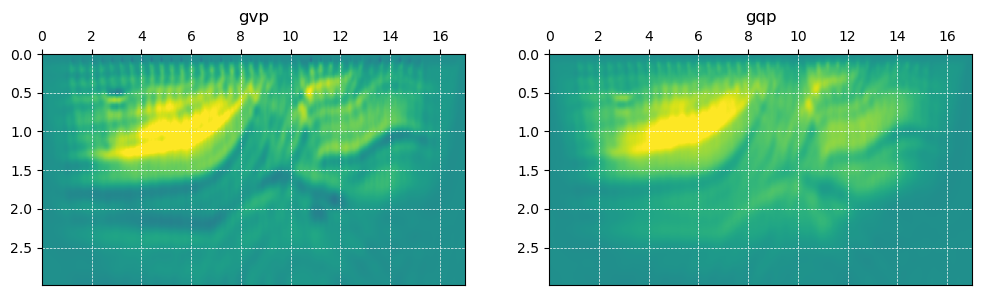

In [48]:
plt.figure(figsize=(12,3))
grad_qp=read('res_smthx0.2_zpow1_NLCG/qp0%pg',n=(2*nx,nz))
plt.subplot(1,2,1); imshow(grad_qp[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad_qp[:,nx:],perc=98,title='gqp')
# imshow(read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz)),perc=98)

In [49]:
!cat res_smthx0.2_zpow1_NLCG/optimization.log

 **********************************************************************
    NONLINEAR CONJUGATE GRADIENT ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =3.22989648E+03
     Initial gradient L1norm (║g0║₁)  =5.5727E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 1.0511E+01 100.000  100.000     -2.85E-02
            1      2  1.00E+00       1.0206E+01                      -2.86E-02   T F
            2      3  1.00E+01       7.5370E+00                      -2.15E-02   T T
     1             3                 7.5370E+00  71.706   79.012     -1.75E-02

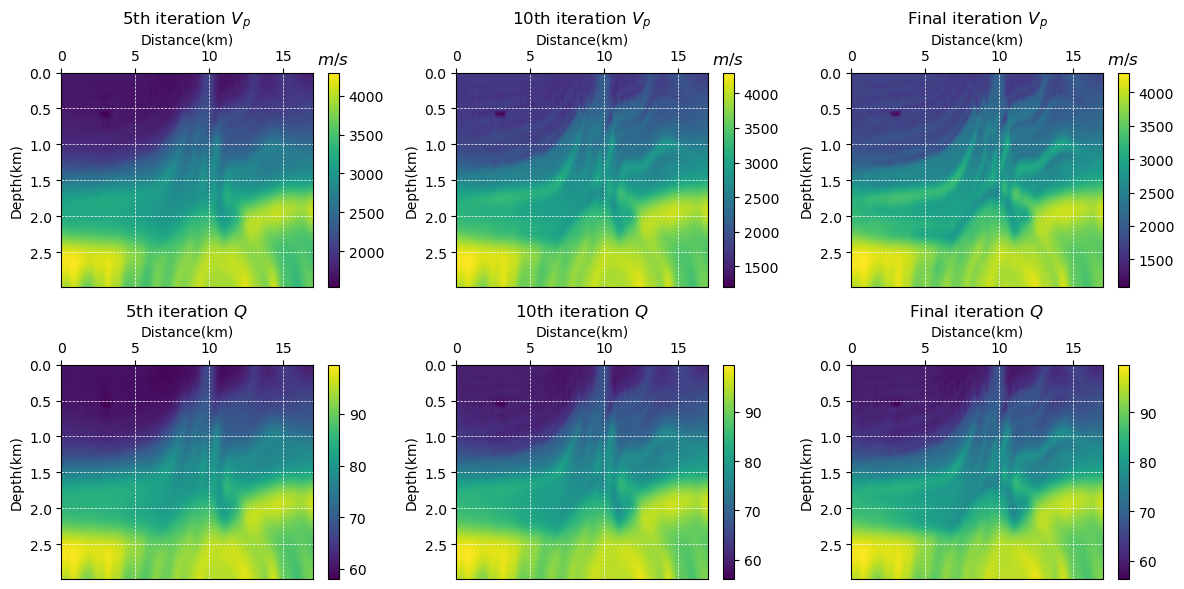

In [50]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(read('res_smthx0.2_zpow1_NLCG/model_Iter5',n=(2*nx,nz))[:,:nx],title=r'5th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,2); imshow(read('res_smthx0.2_zpow1_NLCG/model_Iter10',n=(2*nx,nz))[:,:nx],title=r'10th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,3); imshow(read('res_smthx0.2_zpow1_NLCG/model_final',n=(2*nx,nz))[:,:nx],title=r'Final iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,4); imshow(read('res_smthx0.2_zpow1_NLCG/model_Iter5',n=(2*nx,nz))[:,nx:],title=r'5th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,5); imshow(read('res_smthx0.2_zpow1_NLCG/model_Iter10',n=(2*nx,nz))[:,nx:],title=r'10th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,6); imshow(read('res_smthx0.2_zpow1_NLCG/model_final',n=(2*nx,nz))[:,nx:],title=r'Final iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.tight_layout()
# plt.savefig('./figures/Inversion results.svg',bbox_inches='tight',transparent=True)

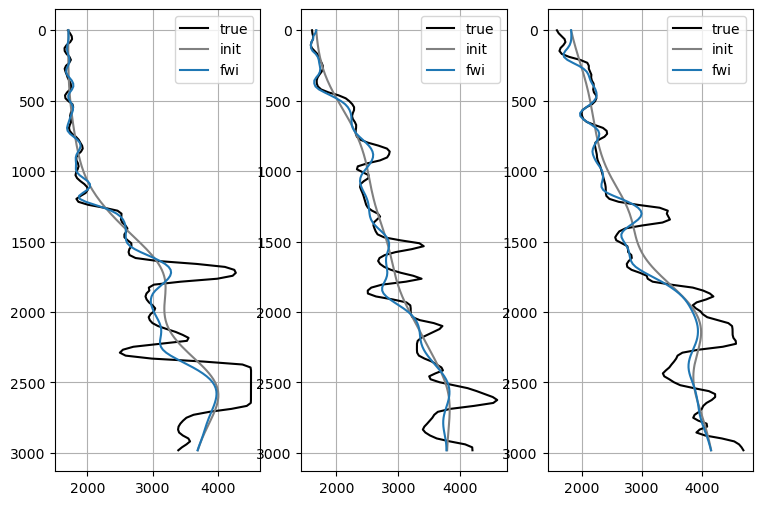

In [51]:
iz=np.arange(nz)*h

# fwi1=read('res_smthx0.2_zpow1/model_final')
fwi1_vp=read('res_smthx0.2_zpow1_NLCG/model_final',n=(2*nx,nz))[:,:nx]
fwi1_qp=read('res_smthx0.2_zpow1_NLCG/model_final',n=(2*nx,nz))[:,nx:]


plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()


In [52]:
true.shape

(143, 2430)

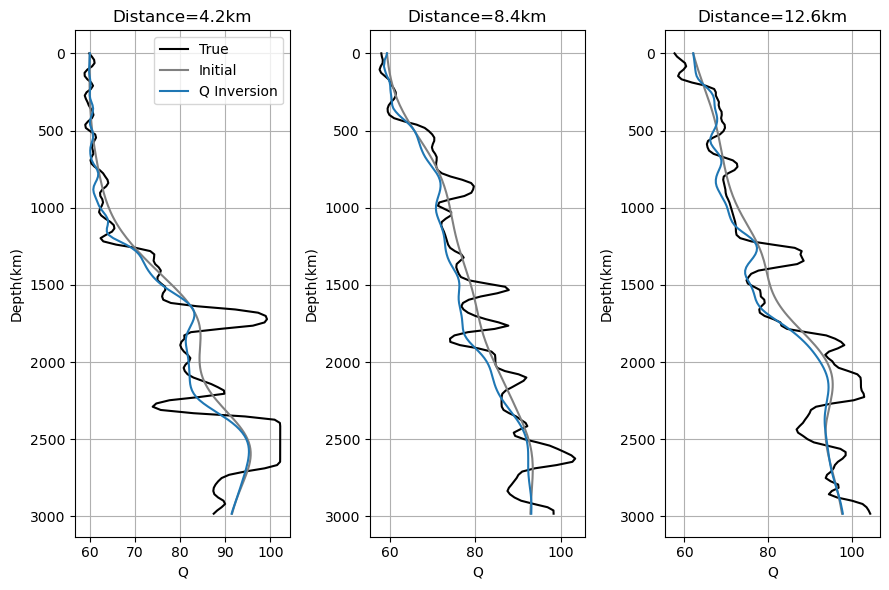

In [53]:
plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Initial',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='Q Inversion')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
# plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,2*nx+ix],iz,label='true',color='k')
plt.plot(init[:,2*nx+ix],iz,label='init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.gca().invert_yaxis()
plt.grid(visible=True)
# plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Q trace comparison.svg',bbox_inches='tight',transparent=True)

### smthx0.2 zpow1 LBFGS

In [11]:
!cp setup_default setup
!rm -r ./res_smthx0.2_zpow1
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1         "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT         p"  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

bash ./run.sh > out


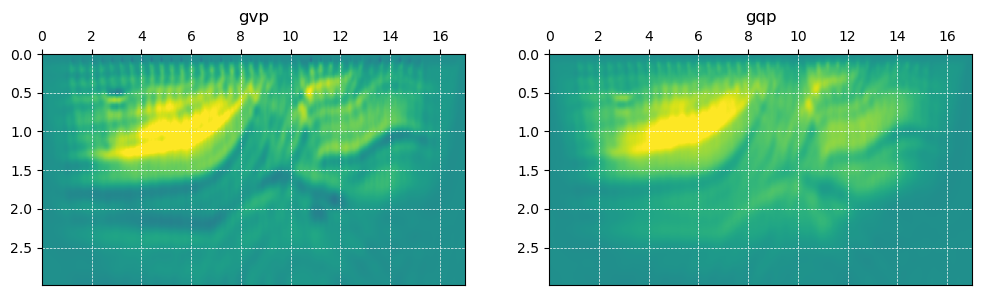

In [14]:
plt.figure(figsize=(12,3))
grad_qp=read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz))
plt.subplot(1,2,1); imshow(grad_qp[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad_qp[:,nx:],perc=98,title='gqp')
# imshow(read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz)),perc=98)

In [19]:
!cat res_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =3.22989648E+03
     Initial gradient L1norm (║g0║₁)  =5.5727E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 1.0511E+01 100.000  100.000     -2.85E-02
            1      2  1.00E+00       1.0206E+01                      -2.86E-02   T F
            2      3  1.00E+01       7.5370E+00                      -2.15E-02   T T
     1             3                 7.5370E+00  71.706   79.009     -1.07E+00
 -------

In [21]:
!cp -r res_smthx0.2_zpow1 res_smthx0.2_zpow1-CP
#done

^C


In [23]:
!cat res_smthx0.2_zpow1/model_final rhot.init > init_contd

In [24]:
!cp setup_default setup
!rm -r ./res_smthx0.2_zpow1_contd
!echo "FILE_MODEL       init_contd         " >> setup
!echo "MODEL_ATTRIBUTES        'vp qp rho' " >> setup
!echo "DIR_OUT         'res_smthx0.2_zpow1_contd' " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1         "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT         p"  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

bash ./run.sh > out


In [31]:
!cat res_smthx0.2_zpow1_contd/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =1.70892812E+04
     Initial gradient L1norm (║g0║₁)  =3.8358E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 9.3900E+00 100.000  100.000     -2.15E-02
            1      2  1.00E+00       9.6101E+00                      -5.00E-03   F T
            2      3  5.00E-01       9.4789E+00                      -1.33E-02   F T
            3      4  2.50E-01       9.4205E+00                      -1.74E-02   F T
  

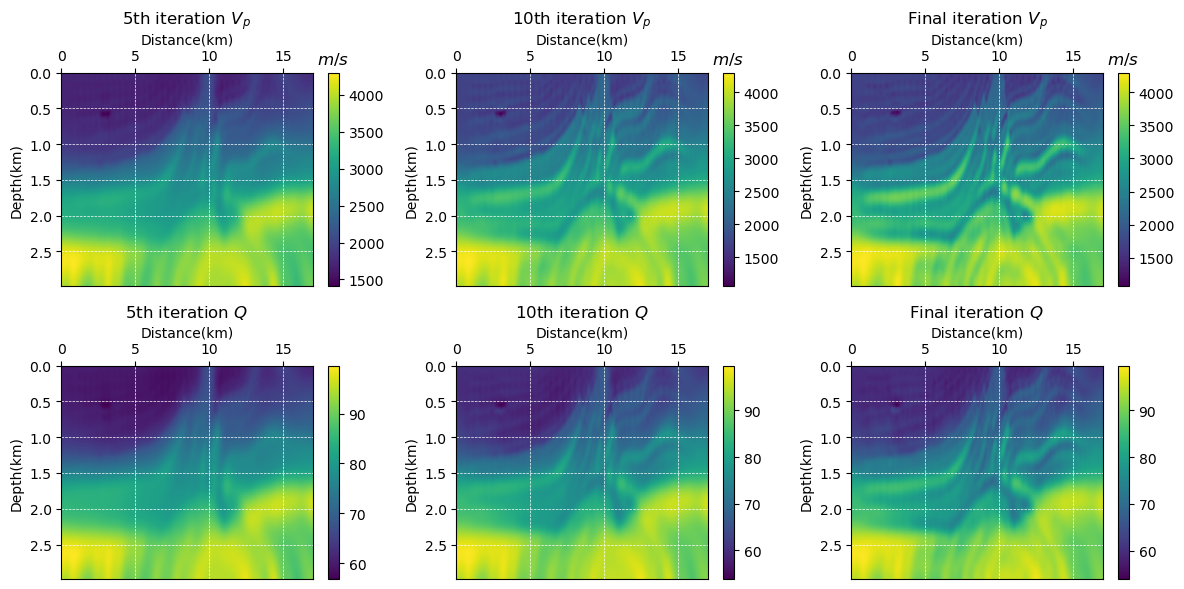

In [32]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); imshow(read('res_smthx0.2_zpow1/model_Iter5',n=(2*nx,nz))[:,:nx],title=r'5th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,2); imshow(read('res_smthx0.2_zpow1/model_Iter10',n=(2*nx,nz))[:,:nx],title=r'10th iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,3); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],title=r'Final iteration $V_{p}$',label=['Distance(km)','Depth(km)'],colorbar_title=r'$m/s$')
plt.subplot(2,3,4); imshow(read('res_smthx0.2_zpow1/model_Iter5',n=(2*nx,nz))[:,nx:],title=r'5th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,5); imshow(read('res_smthx0.2_zpow1/model_Iter10',n=(2*nx,nz))[:,nx:],title=r'10th iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.subplot(2,3,6); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],title=r'Final iteration $Q$',label=['Distance(km)','Depth(km)'],colorbar_title='')
plt.tight_layout()
# plt.savefig('./figures/Inversion results.svg',bbox_inches='tight',transparent=True)

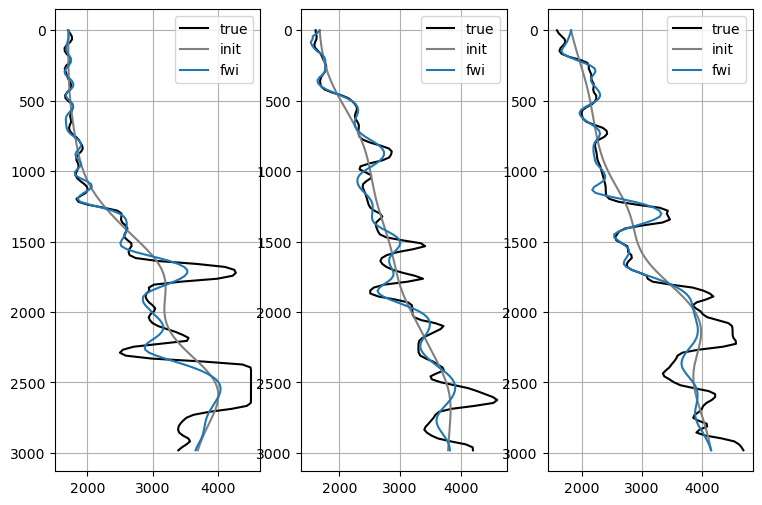

In [35]:
iz=np.arange(nz)*h

# fwi1=read('res_smthx0.2_zpow1/model_final')
fwi1_vp=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]
fwi1_qp=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:]


plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1_vp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()


In [36]:
true.shape

(143, 2430)

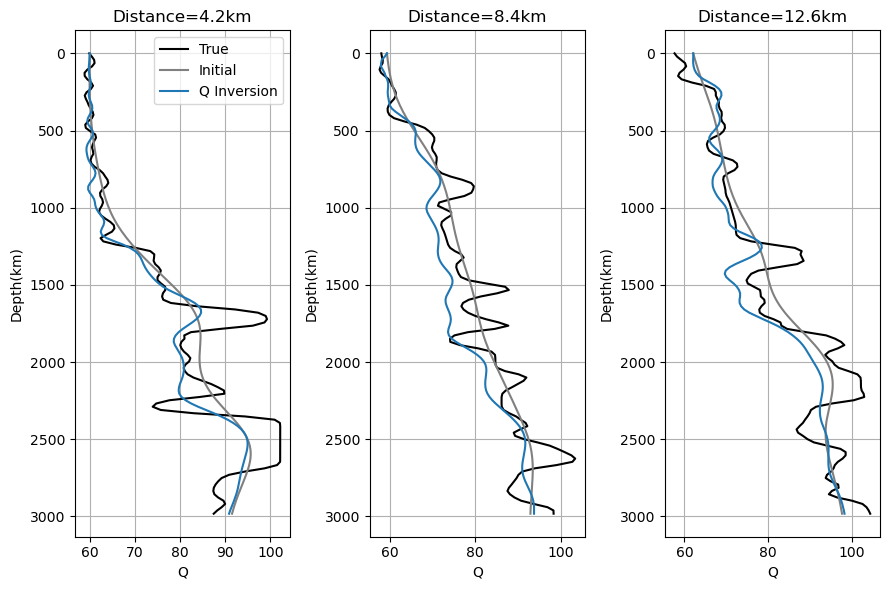

In [37]:
plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Initial',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='Q Inversion')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,2*nx+ix],iz,label='True',color='k')
plt.plot(init[:,2*nx+ix],iz,label='Init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
# plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,2*nx+ix],iz,label='true',color='k')
plt.plot(init[:,2*nx+ix],iz,label='init',color='gray')
plt.plot(fwi1_qp[:,ix],iz,label='fwi')
plt.xlabel('Q')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.gca().invert_yaxis()
plt.grid(visible=True)
# plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Q trace comparison.svg',bbox_inches='tight',transparent=True)

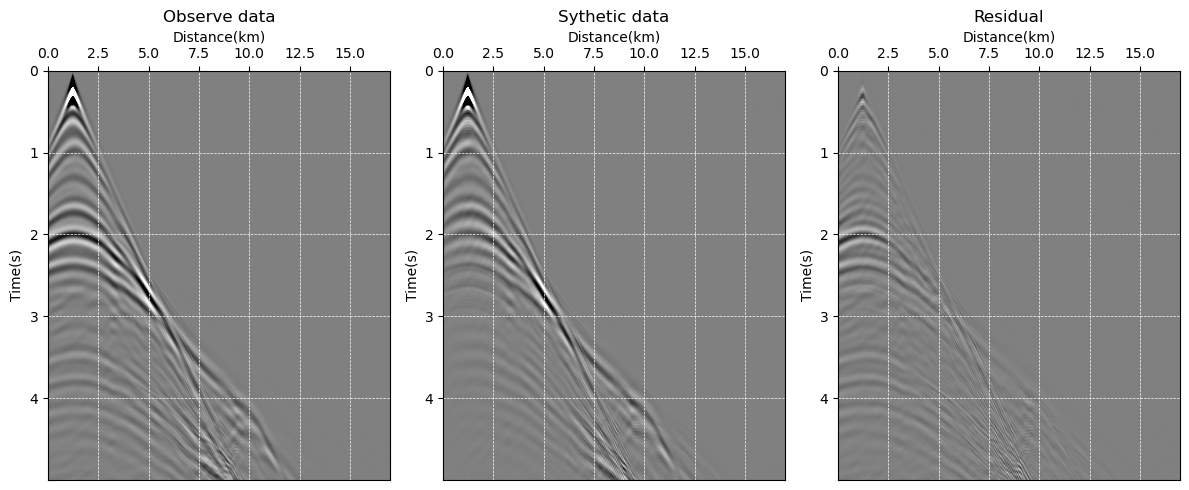

In [42]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_obs/Ru_Shot0001.su'    ),clip=[-0.01,0.01],title='Observe data',label=['Distance(km)','Time(s)'])
plt.subplot(1,3,2); imshow_shot(read_su('res_smthx0.2_zpow1/Ru_Iter18_Shot0001.su' ),clip=[-0.01,0.01],title='Sythetic data',label=['Distance(km)','Time(s)'])
plt.subplot(1,3,3); imshow_shot(read_su('results_obs/Ru_Shot0001.su')-read_su('res_smthx0.2_zpow1/Ru_Iter18_Shot0001.su' ),clip=[-0.01,0.01],title='Residual',label=['Distance(km)','Time(s)'])
plt.tight_layout()
# plt.savefig('./figures/Final data fit.svg',bbox_inches='tight',transparent=True)

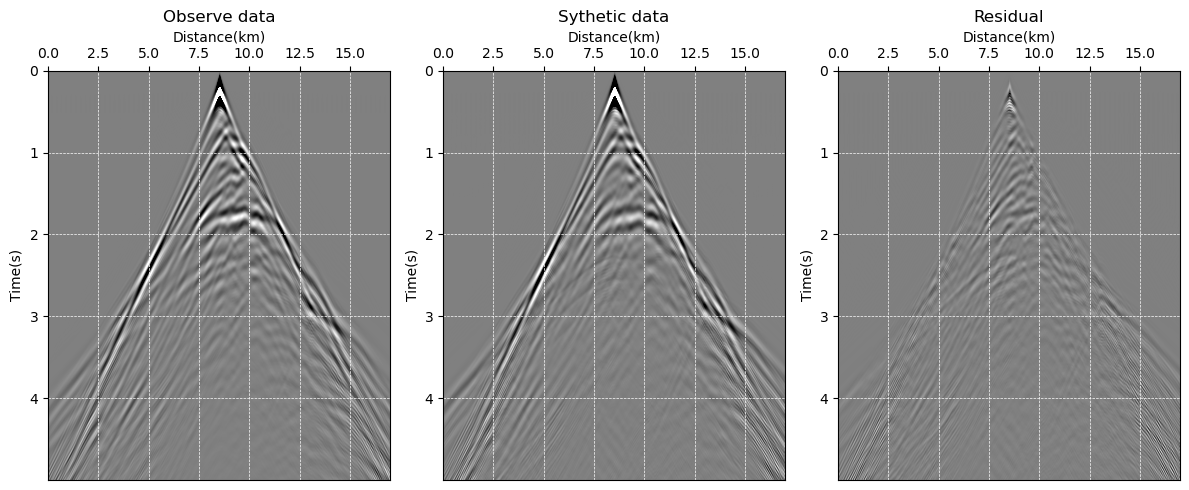

In [40]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_obs/Ru_Shot0019.su'    ),clip=[-0.01,0.01],title='Observe data',label=['Distance(km)','Time(s)'])
plt.subplot(1,3,2); imshow_shot(read_su('res_smthx0.2_zpow1/Ru_Iter18_Shot0019.su' ),clip=[-0.01,0.01],title='Sythetic data',label=['Distance(km)','Time(s)'])
plt.subplot(1,3,3); imshow_shot(read_su('results_obs/Ru_Shot0019.su')-read_su('res_smthx0.2_zpow1/Ru_Iter18_Shot0019.su' ),clip=[-0.01,0.01],title='Residual',label=['Distance(km)','Time(s)'])
plt.tight_layout()
# plt.savefig('./figures/Final data fit.svg',bbox_inches='tight',transparent=True)

### noQ smthx0.2 zpow1

In [398]:
!cp setup_default setup
!rm -r ./res_noQ_smthx0.2_zpow1/
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_noQ_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.2 0.2 0.2' "  >> setup
!echo "PRECO            z^1          "  >> setup
!echo "JOB              optimization " >> setup
!echo "SNAPSHOT      p"  >> setup
!echo "PARAMETER    'vp:1065:4700'"  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

rm: cannot remove './res_noQ_smthx0.2_zpow1/': No such file or directory
bash ./run.sh > out


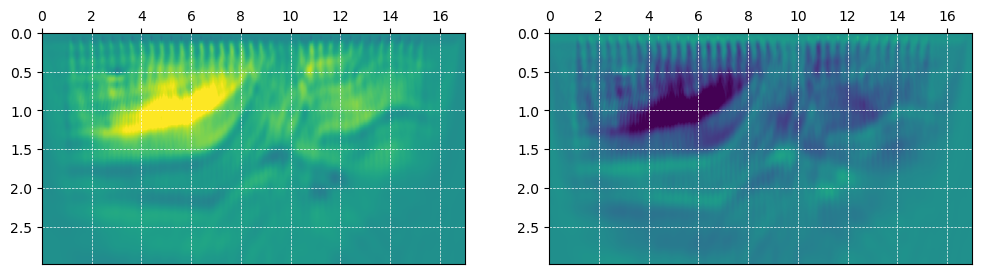

In [406]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1); imshow(read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)
plt.subplot(1,2,2); imshow(read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz))[:,:nx]-read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)

In [407]:
!cat res_noQ_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =   40
     Max linesearches allowed =   12
     Max gradients allowed    =   70
     Linesearch scaler        =1.45596106E+03
     Initial gradient L1norm (║g0║₁)  =3.1867E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 8.3991E+00 100.000  100.000     -1.83E-02
            1      2  1.00E+00       8.0847E+00                      -1.80E-02   T F
            2      3  1.00E+01       6.0886E+00                      -7.42E-03   T T
     1             3                 6.0886E+00  72.491   61.411     -1.40E-01
 -------

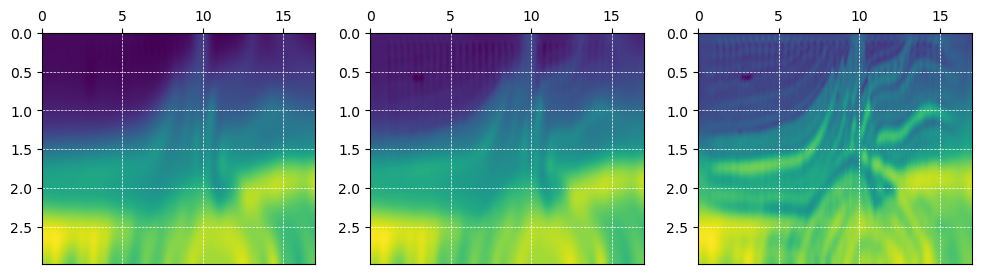

In [408]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter1',n=(2*nx,nz))[:,:nx])
plt.subplot(1,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter4',n=(2*nx,nz))[:,:nx])
plt.subplot(1,3,3); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx])

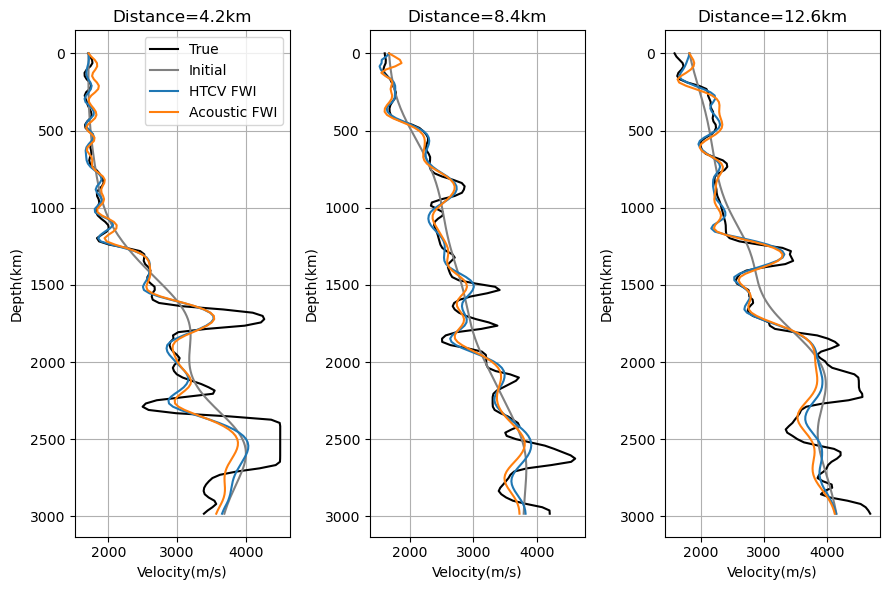

In [410]:
fwi1=read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]
fwi2=read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]

plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='True',color='k')
plt.plot(init[:,ix],iz,label='Initial',color='gray')
plt.plot(fwi1[:,ix],iz,label='HTCV FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.gca().invert_yaxis()
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='Viscoacoustic FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.gca().invert_yaxis()
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.grid(visible=True)
# plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='Viscoacoustic FWI')
plt.plot(fwi2[:,ix],iz,label='Acoustic FWI')
plt.xlabel('Velocity(m/s)')
plt.ylabel('Depth(km)')
plt.title(f'Distance={ix*h/1000}km')
plt.gca().invert_yaxis()
plt.grid(visible=True)
# plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Comparison of Acoustic and Viscoacoustic FWI results_traces.svg',bbox_inches='tight',transparent=True)

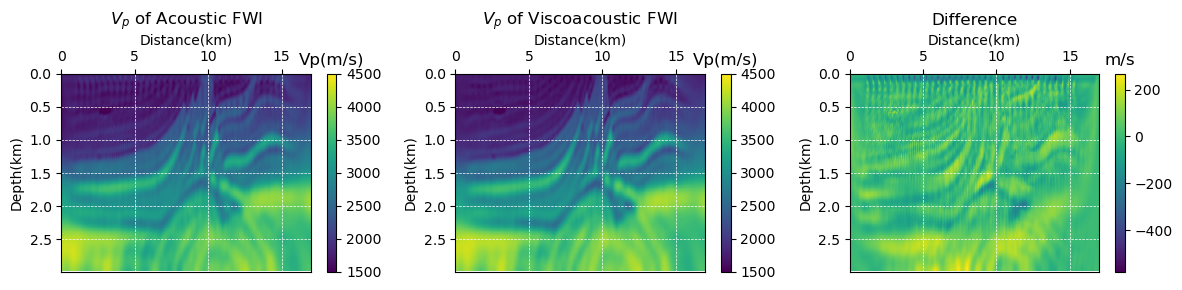

In [411]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title='Vp(m/s)',title=r'$V_p$ of Acoustic FWI',label=['Distance(km)','Depth(km)'])
plt.subplot(1,3,2); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1500,4500],colorbar_title='Vp(m/s)',title=r'$V_p$ of Viscoacoustic FWI',label=['Distance(km)','Depth(km)'])
plt.subplot(1,3,3); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx]-read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],colorbar_title='m/s',title='Difference',label=['Distance(km)','Depth(km)'])
plt.tight_layout()
# plt.savefig('./figures/FWI_result_comparison_with_acoustic.png',bbox_inches='tight',transparent=True)

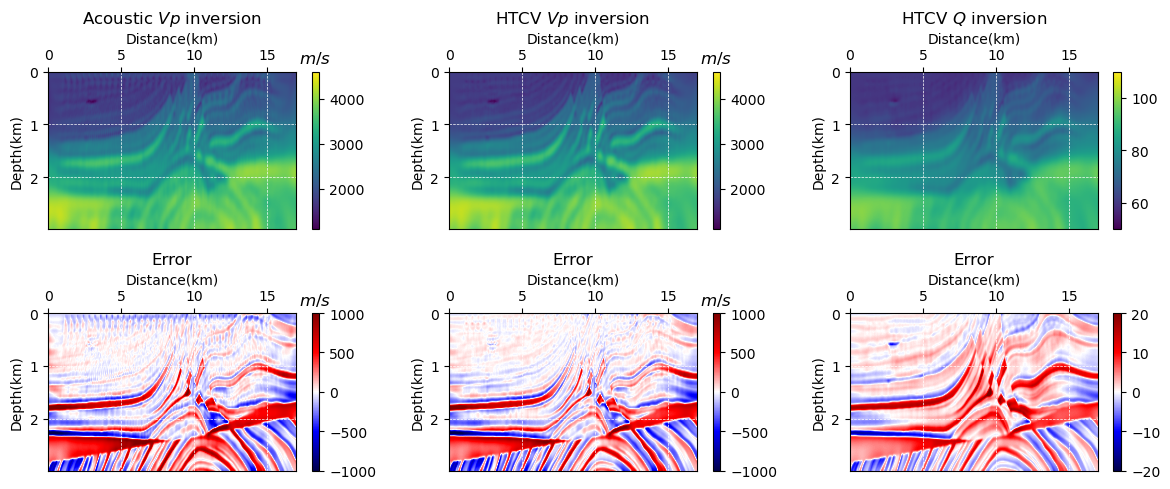

In [412]:
plt.figure(figsize=(12,5))
# plt.subplot(3,3,4); imshow(true[:,:nx],clip=[1500,4500],colorbar_title=r'$m/s$',title=r'True $Vp$',label=['Distance(km)','Depth(km)']) 
plt.subplot(2,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1100,4600],colorbar_title=r'$m/s$',title=r'Acoustic $Vp$ inversion',label=['Distance(km)','Depth(km)']) 
plt.subplot(2,3,4); imshow(true[:,:nx]-read('res_noQ_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[-1000,1000],colorbar_title=r'$m/s$',cmap='seismic',title='Error',label=['Distance(km)','Depth(km)'])
plt.subplot(2,3,2); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[1100,4600],colorbar_title=r'$m/s$',title=r'HTCV $Vp$ inversion',label=['Distance(km)','Depth(km)'])
plt.subplot(2,3,5); imshow(true[:,:nx]-read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,:nx],clip=[-1000,1000],colorbar_title=r'$m/s$',cmap='seismic',title='Error',label=['Distance(km)','Depth(km)'])
# plt.subplot(3,3,7); imshow(true[:,2*nx:],clip=[50,110],colorbar_title=r'',title=r'True $Q$',label=['Distance(km)','Depth(km)']) 
plt.subplot(2,3,3); imshow(read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],clip=[50,110],colorbar_title=r'',title=r'HTCV $Q$ inversion',label=['Distance(km)','Depth(km)']) 
plt.subplot(2,3,6); imshow(true[:,2*nx:]-read('res_smthx0.2_zpow1/model_final',n=(2*nx,nz))[:,nx:],clip=[-20,20],colorbar_title=r'',cmap='seismic',title='Error',label=['Distance(km)','Depth(km)'])
plt.tight_layout()
# plt.savefig('./figures/FWI_result_comparison_with_true.svg',bbox_inches='tight',transparent=True)

## GSLS FWI [not working well]

In [112]:
def run_toyxdac_remote(app='/home/weizhou/Codes/GitHub/legacy_seiscope_fwi/TOYxDAC_TIME/branches/branche_yang/bin/toyxdac_time',
                       np=36,nthreads=1,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ../run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ../run.sh > {out}")

### setups

In [268]:
print(tr.shape)

(1923, 1)


rm: cannot remove 'fwavelet': No such file or directory


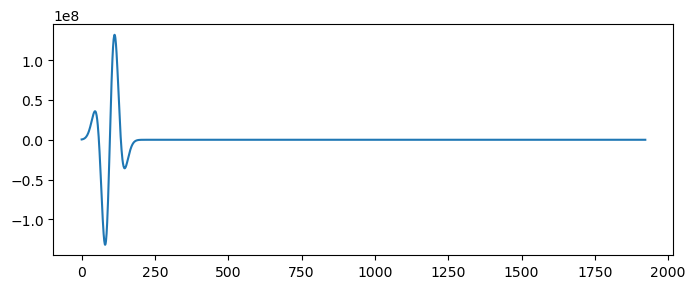

In [269]:
tr=read_su('results_obs/wavelet.su',(1,nt))
tr=np.gradient(tr,axis=0)*-2073577300
#2228017400.0 #ratio of max() @itr=75 of 1st shot
#2073577300.0 #ratio of sum(abs()) @itr=75 of 1st shot

!rm fwavelet
tr.astype('float32').tofile('fwavelet')

plt.figure(figsize=(8,3))
plt.plot(read('fwavelet',n=(1,nt)))

In [270]:
#acquisition

src_list = np.arange(1200,1200+400*36,400)
print(src_list)
print(len(src_list))

rcv_list = np.arange(0,25*670,25)
print(rcv_list)
print(len(rcv_list))

ntr=len(rcv_list)


with open('acqui', 'w') as f:
    
    for src in src_list:
        f.write(f'21 {src} 0  0 0 0\n')  # sz, sx, sy
    
        for rcv in rcv_list:
            f.write(f'21 {rcv} 0  0 0 1\n')  # rz, rx, ry

[ 1200  1600  2000  2400  2800  3200  3600  4000  4400  4800  5200  5600
  6000  6400  6800  7200  7600  8000  8400  8800  9200  9600 10000 10400
 10800 11200 11600 12000 12400 12800 13200 13600 14000 14400 14800 15200]
36
[    0    25    50    75   100   125   150   175   200   225   250   275
   300   325   350   375   400   425   450   475   500   525   550   575
   600   625   650   675   700   725   750   775   800   825   850   875
   900   925   950   975  1000  1025  1050  1075  1100  1125  1150  1175
  1200  1225  1250  1275  1300  1325  1350  1375  1400  1425  1450  1475
  1500  1525  1550  1575  1600  1625  1650  1675  1700  1725  1750  1775
  1800  1825  1850  1875  1900  1925  1950  1975  2000  2025  2050  2075
  2100  2125  2150  2175  2200  2225  2250  2275  2300  2325  2350  2375
  2400  2425  2450  2475  2500  2525  2550  2575  2600  2625  2650  2675
  2700  2725  2750  2775  2800  2825  2850  2875  2900  2925  2950  2975
  3000  3025  3050  3075  3100  3125  3150  317

### forward modeling

In [87]:
!mkdir gsls_fwd

In [271]:
%%writefile gsls_fwd/toyxdac_time_input
0           ! mode 0->FWM, 1->FWI, 2->RTM, 3-> FWI for source estimation, 4-> Single FWI gradient
3           ! 1:ISO, 2:VTI, 3:viscous ISO, 4:viscous VTI
1           ! acquisition mode 1-> standard acqui file, 2->acqui read in SU header (only for FWI and RTM) 
'../acqui'  ! acquisition file for acquisition  mode = 1

Overwriting gsls_fwd/toyxdac_time_input


In [275]:
with open('gsls_fwd/fdtd_input', 'w') as f:
    f.write(f'{nz} {nx} 1    \n')  # nz,nx,ny 
    f.write(f'{h}            \n')  # h
    f.write(f"'../vpt.21m' '../rhot.21m'  \n")  # vp, rho
    f.write(f'2 20           \n')  # type of boundary and size boundary
    f.write(f'4              \n')  # order of the scheme 4 or 8
    f.write(f"'../fwavelet'  \n")  # source file
    f.write(f'1              \n')  # ihicks
    f.write(f'{fpeak}        \n')  # reference frequency
    f.write(f'{nt} {dt} {nt} \n')  # nts, dt, nt
    f.write(f'2              \n')  # type of source, 1:pressure, 2:vertical force, 3:horizontal x force, 4:horizontal y force
    f.write(f'1              \n')  # freesurf, 1:yes, 0:no
    f.write(f'ftopo          \n')  # topo file, not needed for forward modeling
    f.write(f'0 0 0 1        \n')  # component P, vx,vy,vz

In [273]:
%%writefile gsls_fwd/attenuation_input
'../qpt.21m'     !file for quality factor
3           !number of attenaution mechanisms
0.3  10     !fmin & fmax
12 0.001 1  !number of checkpoints and tolerance, best default nc=log2(nt); tolerance=0.1%,icarfs=0,standard checkpointing

Overwriting gsls_fwd/attenuation_input


In [209]:
run_toyxdac_remote(np=1,out='out')

bash ../run.sh > out


In [255]:
!cat gsls_fwd/out


            Welcome to TOYxDAC_Time code              
               VTI visco-acoustic FWI                 

 code launched in 2d mode
 with modeling of order           4
 read acquisition
 mype=           0 ok,  isrc=           1
 mype           0 acqui%nrec         670
  mype:           0 ; my source (z,x,y):    21.0000000       1200.00000       0.00000000    
  direct/forward simulation in the time domain
 computing box=[n1min,n1max] x [n2min,n2max] x [n3min,n3max]
   [n1min,n1max]:         -21         165
   [n2min,n2max]:         -21         832
   [n3min,n3max]:           1           1
 number of GMB mechanisms:           3
 yl for Q approximation:   1.55374348      0.906662941       1.58571935    
 reference frequencies:  0.300000012       1.73205078       10.0000000    
 number of checkpoints:           0
 qpmod   48.5923615       104.530281    
 vpmod   1142.89246       4691.61230    
 rhomod   1688.35657       2622.54517    
 epsilonmod   0.00000000       0.00000000    
 d

/tmp/ipykernel_578792/495260318.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,3,1); imshow_shot(read_su('results_obs/Ru_Shot0001.su'),   clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])


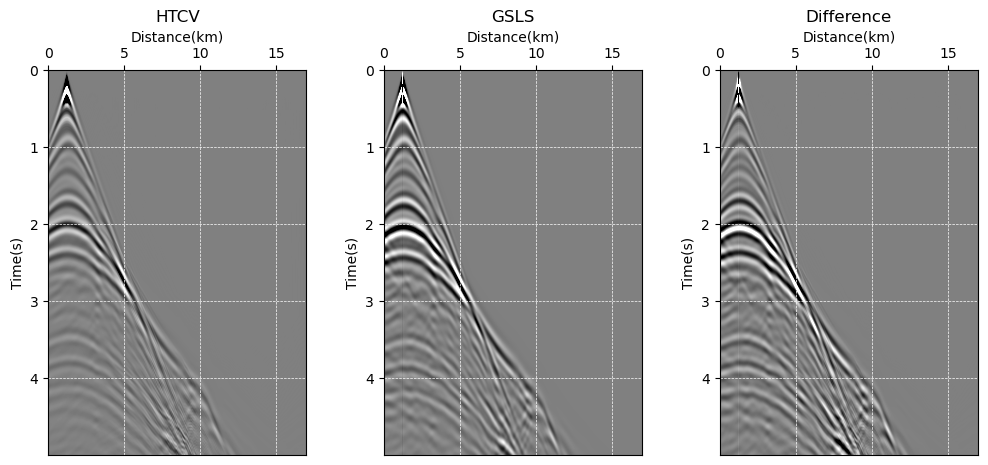

In [253]:
fig,ax=plt.subplots(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_obs/Ru_Shot0001.su'),  clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow_shot(read('gsls_fwd/fsismos_z0000',(ntr,nt)),clip=[-0.01,0.01],title='GSLS',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,3); imshow_shot(read_su('results_obs/Ru_Shot0001.su')-read('gsls_fwd/fsismos_z0000',(ntr,nt)),
                                clip=[-0.01,0.01],title='Difference',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplots_adjust(wspace=0.3)
# plt.savefig('./figures/results_with_Q.svg',bbox_inches='tight',transparent=True)

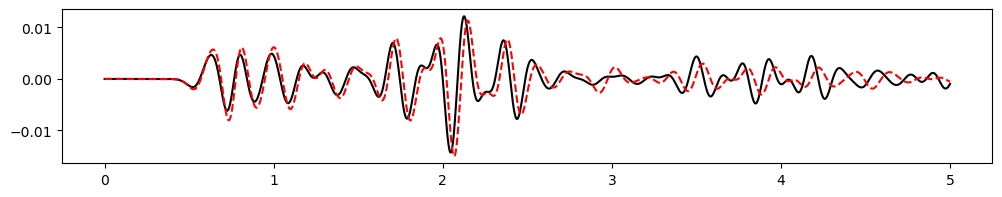

In [254]:
t=np.linspace(0,dt*nt,nt)

tr1 = read_su('results_obs_noQ/Ru_Shot0001.su') [:,75]
tr2 = read(   'gsls_fwd/fsismos_z0000',(ntr,nt))[:,75]

plt.figure(figsize=(12,2))
plt.plot(t,tr1,color='k')
plt.plot(t,tr2,'--r')

'Residual' diff due to different attenuation mech..  
If no attenuation, the two traces match perfectly.

### binary data

In [262]:
!mkdir gsls_data

In [346]:
for i in range(36):
    fin=f'results_obs/Ru_Shot{i+1:04d}.su'
    su = read_su(fin,(ntr,nt))
    
    fout=f'gsls_data/obs_{i:04d}'
    su.T.astype('float32').tofile(fout)
    
    print(fin,'->',fout)
    
# for su in `ls results_obs/Ru_Shot????.su`; do
#     sustrip < $su > gsls_data/obs_${su:19:4}
# done

results_obs/Ru_Shot0001.su -> gsls_data/obs_0000
results_obs/Ru_Shot0002.su -> gsls_data/obs_0001
results_obs/Ru_Shot0003.su -> gsls_data/obs_0002
results_obs/Ru_Shot0004.su -> gsls_data/obs_0003
results_obs/Ru_Shot0005.su -> gsls_data/obs_0004
results_obs/Ru_Shot0006.su -> gsls_data/obs_0005
results_obs/Ru_Shot0007.su -> gsls_data/obs_0006
results_obs/Ru_Shot0008.su -> gsls_data/obs_0007
results_obs/Ru_Shot0009.su -> gsls_data/obs_0008
results_obs/Ru_Shot0010.su -> gsls_data/obs_0009
results_obs/Ru_Shot0011.su -> gsls_data/obs_0010
results_obs/Ru_Shot0012.su -> gsls_data/obs_0011
results_obs/Ru_Shot0013.su -> gsls_data/obs_0012
results_obs/Ru_Shot0014.su -> gsls_data/obs_0013
results_obs/Ru_Shot0015.su -> gsls_data/obs_0014
results_obs/Ru_Shot0016.su -> gsls_data/obs_0015
results_obs/Ru_Shot0017.su -> gsls_data/obs_0016
results_obs/Ru_Shot0018.su -> gsls_data/obs_0017
results_obs/Ru_Shot0019.su -> gsls_data/obs_0018
results_obs/Ru_Shot0020.su -> gsls_data/obs_0019
results_obs/Ru_Shot0

### inversion

In [276]:
!mkdir gsls_inv

mkdir: cannot create directory ‘gsls_inv’: File exists


In [377]:
%%writefile gsls_inv/toyxdac_time_input
1           ! mode 0->FWM, 1->FWI, 2->RTM, 3-> FWI for source estimation, 4-> Single FWI gradient
3           ! 1:ISO, 2:VTI, 3:viscous ISO, 4:viscous VTI
1           ! acquisition mode 1-> standard acqui file, 2->acqui read in SU header (only for FWI and RTM) 
'../acqui'  ! acquisition file for acquisition  mode = 1

Overwriting gsls_inv/toyxdac_time_input


In [378]:
with open('gsls_inv/fdtd_input', 'w') as f:
    f.write(f'{nz} {nx} 1    \n')  # nz,nx,ny 
    f.write(f'{h}            \n')  # h
    f.write(f"'../vpt.init' '../rhot.init'  \n")  # vp, rho
    f.write(f'1 40           \n')  # type of boundary and size boundary
    f.write(f'4              \n')  # order of the scheme 4 or 8
    f.write(f"'../fwavelet'  \n")  # source file
    f.write(f'1              \n')  # ihicks
    f.write(f'{fpeak}        \n')  # reference frequency
    f.write(f'{nt} {dt} {nt} \n')  # nts, dt, nt
    f.write(f'2              \n')  # type of source, 1:pressure, 2:vertical force, 3:horizontal x force, 4:horizontal y force
    f.write(f'1              \n')  # freesurf, 1:yes, 0:no
    f.write(f'ftopo          \n')  # topo file, not needed for forward modeling
    f.write(f'0 0 0 1        \n')  # component P, vx,vy,vz

In [379]:
%%writefile gsls_inv/attenuation_input
'../qpt.init'     !file for quality factor
3           !number of attenaution mechanisms
0.3  10     !fmin & fmax
116 0.001 1  !number of checkpoints and tolerance, best default nc=log2(nt); tolerance=0.1%,icarfs=0,standard checkpointing

Overwriting gsls_inv/attenuation_input


In [380]:
topo=np.zeros((nx,1))
topo.T.astype('float32').tofile('gsls_inv/ftopo')

weight=np.ones((5,1))
weight[0:3]=0.
weight.T.astype('float32').tofile('gsls_inv/fweight')

In [381]:
%%writefile gsls_inv/fmute
0  0    !i_fmute,i_tmute, 0: no mute
1  1 0  !nmute, gain, ntaper
1       !xmute array
0       !tmute array

Overwriting gsls_inv/fmute


In [382]:
with open('gsls_inv/fwi_input', 'w') as f:
    f.write(f'0 0 0 1                      \n') # data component P, vx,vy,vz
    f.write(f"ti to ta '../gsls_data/obs_' \n") # name of observed data
    f.write(f'1                            \n') # family, 0:kappa-rho, 1:vp-rho, 2:vp-ip
    f.write(f'2 1 3                        \n') # number of parameters. index of reconstructed parameters: family1: 1:vp,2:rho,3:qp
    f.write(f'4 5 1e-8 100  1              \n') # optimization algo, memory, convergence criteria, max number of iteration, precondition option(0,1,2)
    f.write('1  1065 4700  10 100          \n') # bound constraints active(1) or not (0), vpmin,vpmax,rhomin,rhomax,qpmin,qpmax)
    f.write(f'-1 0.2 0.2 0.2               \n') # activate smoothing, lambda_x,lambda_y,lambda_z
    f.write(f'ftopo                        \n') # file name of bathymetry
    f.write(f'0.                           \n') # transition zone from water bottom to gradient 
    f.write(f'fweight                      \n') #file name of the data weighting
    f.write(f'5 25.                        \n') #number of point and sampling of the data weighting file 
    f.write(f'fmute                        \n') #mute file
    f.write(f'{dt}                         \n') #dt for saving field on boundary
    f.write(f'{10*dt}                      \n') #stop before 0s during backpropagation to avoid strong artefacts near source

In [383]:
run_toyxdac_remote(out='out')

bash ../run.sh > out


/tmp/ipykernel_578792/2645742242.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,3,1); imshow_shot(read_su('results_grad/Ru_Shot0001.su'), clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])


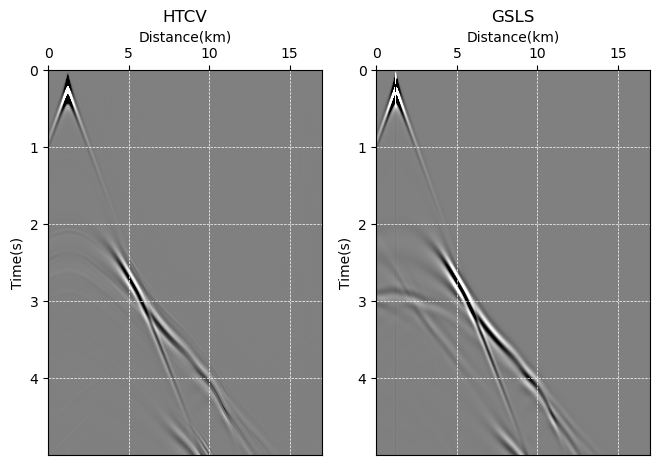

In [314]:
fig,ax=plt.subplots(figsize=(12,5))
plt.subplot(1,3,1); imshow_shot(read_su('results_grad/Ru_Shot0001.su'), clip=[-0.01,0.01],title='HTCV',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
plt.subplot(1,3,2); imshow_shot(read('gsls_inv/synth_z0000',(ntr,nt)),clip=[-0.01,0.01],title='GSLS',label=['Distance(km)','Time(s)'])
ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplot(1,3,3); imshow_shot(read_su('results_obs/Ru_Shot0001.su')-read('gsls_fwd/fsismos_z0000',(ntr,nt)),
#                                 clip=[-0.01,0.01],title='Difference',label=['Distance(km)','Time(s)'])
# ax = plt.gca(); ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()
# plt.subplots_adjust(wspace=0.3)
# plt.savefig('./figures/results_with_Q.svg',bbox_inches='tight',transparent=True)

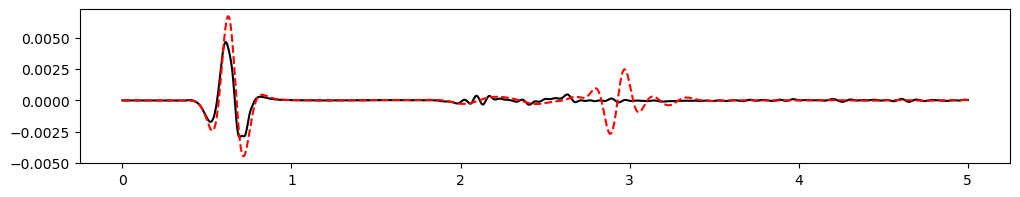

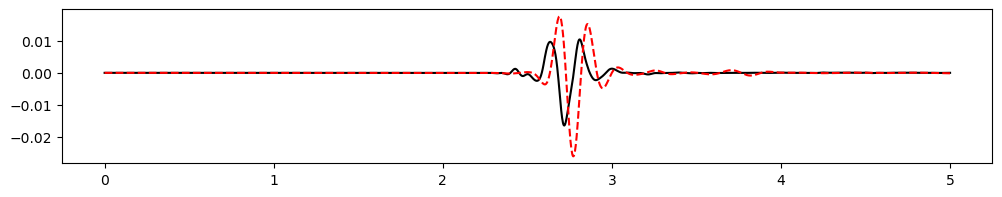

In [315]:
t=np.linspace(0,dt*nt,nt)

tr1 = read_su('results_grad/Ru_Shot0001.su')   [:,75]
tr2 = read(   'gsls_inv/synth_z0000',(ntr,nt))[:,75]

plt.figure(figsize=(12,2))
plt.plot(t,tr1,color='k')
plt.plot(t,tr2,'--r')

tr1 = read_su('results_grad/Ru_Shot0001.su')  [:,200]
tr2 = read(   'gsls_inv/synth_z0000',(ntr,nt))[:,200]

plt.figure(figsize=(12,2))
plt.plot(t,tr1,color='k')
plt.plot(t,tr2,'--r')

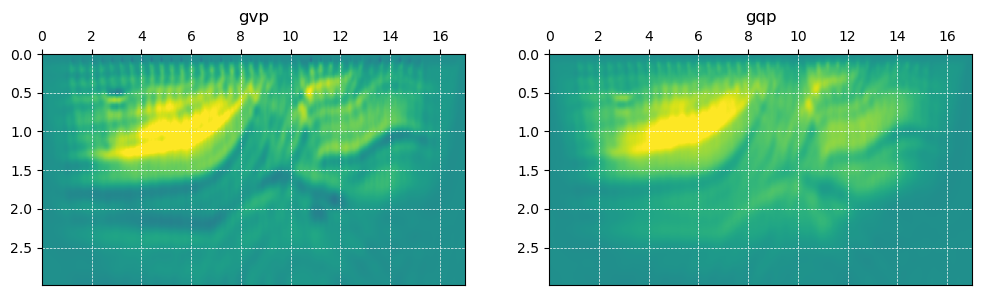

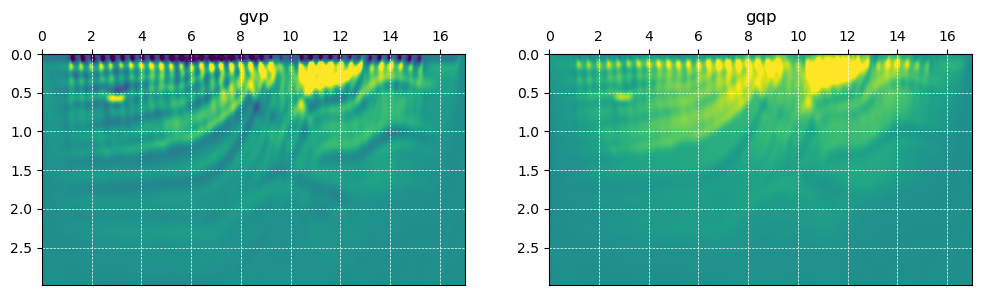

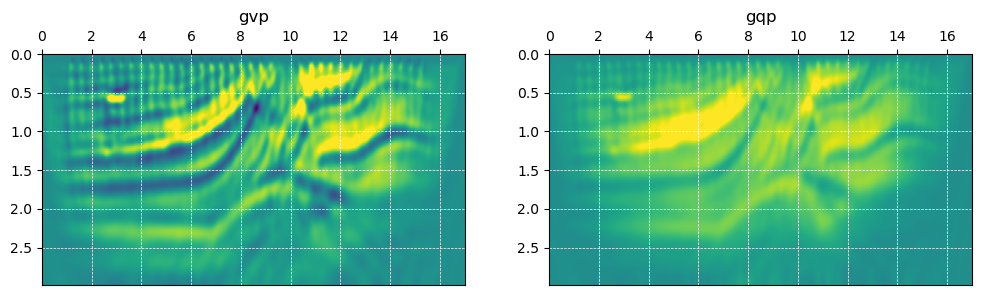

In [370]:
plt.figure(figsize=(12,3))
grad=read('res_smthx0.2_zpow1/qp0%pg',n=(2*nx,nz))
plt.subplot(1,2,1); imshow(grad[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad[:,nx:],perc=98,title='gqp')


plt.figure(figsize=(12,3))
#first gradient
#by playing with toyxdac_time_input

grad=read('gsls_inv/firstgradient',n=(2*nx,nz))
plt.subplot(1,2,1); imshow(grad[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad[:,nx:],perc=98,title='gqp')

plt.figure(figsize=(12,3))

z=np.linspace(0,h/1e3*nz,nz)
zpow=z**1
grad=read('gsls_inv/firstgradient',n=(2*nx,nz))
for ix in range(2*nx): grad[:,ix]*=zpow

plt.subplot(1,2,1); imshow(grad[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(grad[:,nx:],perc=98,title='gqp')

In [395]:
!cat gsls_inv/out


            Welcome to TOYxDAC_Time code              
               VTI visco-acoustic FWI                 

 code launched in 2d mode
 with modeling of order           4
 read acquisition
 mype=           0 ok,  isrc=           1
 mype           0 acqui%nrec         670
  mype:           0 ; my source (z,x,y):    21.0000000       1200.00000       0.00000000    
 mype=           1 ok, isrc=           2
 mype           1 acqui%nrec         670
  mype:           1 ; my source (z,x,y):    21.0000000       1600.00000       0.00000000    
 mype=           2 ok, isrc=           3
  fwi for medium parameters in the time domain
 lower bounds of parameters:   1065.00000       10.0000000    
 upper bounds of parameters:   4700.00000       100.000000    
 mype=           3 ok, isrc=           4
 mype           2 acqui%nrec         670
  mype:           2 ; my source (z,x,y):    21.0000000       2000.00000       0.00000000    
 mype           3 acqui%nrec         670
  mype:           3 ; my so

In [394]:
!cat gsls_inv/iterate_PLB.dat

**********************************************************************
             PRECONDITIONED l-BFGS ALGORITHM      
**********************************************************************
     Convergence criterion  :   1.00E-08
     Niter_max              :     100
     Initial cost is        :   2.16E+07
     Initial norm_grad is   :   1.44E+03
**********************************************************************
   Niter     fk        ||gk||      fk/f0       alpha       nls     ngrad    
     0    2.16E+07    1.44E+03    1.00E+00    1.00E+00       0       0
     1    1.97E+07    1.29E+03    9.13E-01    1.00E+00       0       1
     2    1.82E+07    1.90E+03    8.44E-01    1.00E+00       0       2
     3    1.71E+07    2.58E+03    7.91E-01    1.00E+01       1       4
**********************************************************************
                      STOP: LINESEARCH FAILURE    
**********************************************************************
